In [1]:
from pathlib import Path
import pandas as pd
import torch
import matplotlib.pyplot as plt
import xarray as xr
import yaml
import geopandas as gpd
import numpy as np
import pickle
import itertools
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
import contextily as cx

import geopandas as gpd
from shapely.geometry import Point

In [2]:
# --------------- Paths ---------------
extended_dataset_dir=Path(f"../../extending_caravan/data/time_series")
data_camels=Path("/inputs/basin_dataset_public_v1p2/basin_mean_forcing/daymet") #camels
data_caravan=Path("/inputs/data_updated_2/time_series")
location_file = Path('../../extending_caravan/data/attributes/attributes_other.csv')
basins_path = Path("../../extending_caravan/basins_excluded.txt")
ATTRIBUTES_FILE = Path('../../extending_caravan/data/attributes/attributes_caravan.csv')

In [3]:
# def plot_precipitation_comparison(
#     basin: str,
#     extended_dataset_dir: Path,
#     data_caravan: Path,
#     data_camels: Path,
#     start_date: str = "1989-10-01",
#     end_date: str = "2008-09-30",
#     vmax_heatmap: float = 7.0,
#     save_path: Path = None,
# ):
#     """
#     Plot precipitation comparison for a single basin across four products:
#     CARAVAN, CAMELS (gauge), CHIRPS, and MSWEP.

#     Parameters
#     ----------
#     basin : str
#         Basin ID, e.g. "camels_us_01013500"
#     extended_dataset_dir : Path
#         Directory containing extended NetCDF files (with CHIRPS/MSWEP).
#     data_caravan : Path
#         Directory containing original Caravan NetCDF files.
#     data_camels : Path
#         Directory containing CAMELS gauge txt files.
#     start_date : str
#         Start of analysis period (inclusive), default "1989-10-01".
#     end_date : str
#         End of analysis period (inclusive), default "2008-09-30".
#     vmax_heatmap : float
#         Max value for the seasonal heatmap colorbar, default 7.
#     save_path : Path, optional
#         If provided, saves the figure to this path instead of showing it.
#     """
#     number = basin.split("_")[-1]

#     # ------------------------------------------------------------------ #
#     # Load data
#     # ------------------------------------------------------------------ #
#     camels_nc = xr.open_dataset(extended_dataset_dir / f"{basin}.nc")
    
#     csv_files = list(data_camels.glob(f"**/{number}*.txt"))
#     if not csv_files:
#         print(f"No gauge CSV found for {basin} — skipping.")
#         return
    
#     df_gauge = pd.read_csv(csv_files[0], skiprows=3, sep=r"\s+")
#     df_gauge["date"] = pd.to_datetime(
#         df_gauge[["Year", "Mnth", "Day"]].rename(
#             columns={"Year": "year", "Mnth": "month", "Day": "day"}
#         )
#     )
#     df_gauge = df_gauge.set_index("date")

#     # ------------------------------------------------------------------ #
#     # Build xarray DataArrays
#     # ------------------------------------------------------------------ #
#     precip_caravan = camels_nc["total_precipitation_sum"]
#     precip_chirps  = camels_nc["chirps_precipitation"]
#     precip_mswep   = camels_nc["mswep_precipitation"]
#     precip_camels  = xr.DataArray(
#         df_gauge["prcp(mm/day)"],
#         coords={"date": df_gauge.index},
#         dims="date",
#         name="prcp",
#     )

#     # ------------------------------------------------------------------ #
#     # Align and slice
#     # ------------------------------------------------------------------ #
#     precip_caravan, precip_camels, precip_chirps, precip_mswep = xr.align(
#         precip_caravan, precip_camels, precip_chirps, precip_mswep, join="inner"
#     )

#     t0, t1 = pd.Timestamp(start_date), pd.Timestamp(end_date)
#     sl = slice(t0, t1)

#     caravan = precip_caravan.sel(date=sl)
#     camels  = precip_camels.sel(date=sl)
#     chirps  = precip_chirps.sel(date=sl)
#     mswep   = precip_mswep.sel(date=sl)

#     # ------------------------------------------------------------------ #
#     # Cumulative sums
#     # ------------------------------------------------------------------ #
#     cum_caravan = caravan.cumsum(dim="date").values.flatten()
#     cum_camels  = camels.cumsum(dim="date").values.flatten()
#     cum_chirps  = chirps.cumsum(dim="date").values.flatten()
#     cum_mswep   = mswep.cumsum(dim="date").values.flatten()

#     # ------------------------------------------------------------------ #
#     # Flow duration curve helpers
#     # ------------------------------------------------------------------ #
#     def _fdc(da):
#         arr = da.values.flatten()
#         arr = arr[~np.isnan(arr)]
#         arr_sorted = np.sort(arr)[::-1]
#         ep = np.arange(1, len(arr_sorted) + 1) / (len(arr_sorted) + 1) * 100
#         arr_plot = np.where(arr_sorted == 0, 1e-5, arr_sorted)
#         return ep, arr_plot

#     ep_caravan, pr_caravan_plot = _fdc(caravan)
#     ep_camels,  pr_camels_plot  = _fdc(camels)
#     ep_chirps,  pr_chirps_plot  = _fdc(chirps)
#     ep_mswep,   pr_mswep_plot   = _fdc(mswep)

#     # ------------------------------------------------------------------ #
#     # Dry spell lengths
#     # ------------------------------------------------------------------ #
#     def _dry_lengths(da):
#         mask = (da.values.flatten() == 0)
#         diff = np.diff(mask.astype(int))
#         starts = np.where(diff == 1)[0] + 1
#         ends   = np.where(diff == -1)[0] + 1
#         if mask[0]:  starts = np.r_[0, starts]
#         if mask[-1]: ends   = np.r_[ends, len(mask)]
#         return ends - starts

#     dry_caravan = _dry_lengths(caravan)
#     dry_camels  = _dry_lengths(camels)
#     dry_chirps  = _dry_lengths(chirps)
#     dry_mswep   = _dry_lengths(mswep)

#     bins = np.arange(1, max(dry_caravan.max(), dry_camels.max(),
#                             dry_chirps.max(), dry_mswep.max()) + 2) - 0.5

#     # ------------------------------------------------------------------ #
#     # Seasonal cycle (median by DOY)
#     # ------------------------------------------------------------------ #
#     dates = pd.to_datetime(caravan.date.values)
#     df_doy = pd.DataFrame({
#         "doy":     dates.dayofyear,
#         "caravan": caravan.values,
#         "camels":  camels.values,
#         "chirps":  chirps.values,
#         "mswep":   mswep.values,
#     })

#     def _median_doy(col):
#         med = df_doy.groupby("doy")[col].median().values
#         return med[:365] if len(med) == 366 else med

#     all_precip = np.array([
#         _median_doy("caravan"),
#         _median_doy("camels"),
#         _median_doy("chirps"),
#         _median_doy("mswep"),
#     ])

#     # ------------------------------------------------------------------ #
#     # Plot
#     # ------------------------------------------------------------------ #
#     fig, ax = plt.subplots(2, 2, figsize=(10, 8))
#     fig.suptitle(f"Basin: {basin}", fontsize=13, fontweight="bold")

#     # A) Cumulative
#     max_val = max(cum_caravan.max(), cum_camels.max(),
#                   cum_chirps.max(), cum_mswep.max())
#     ax[0, 0].plot(cum_caravan, cum_camels, label="CAMELS")
#     ax[0, 0].plot(cum_caravan, cum_chirps, label="CHIRPS")
#     ax[0, 0].plot(cum_caravan, cum_mswep,  label="MSWEP")
#     ax[0, 0].plot([0, max_val], [0, max_val], "r--", label="1:1 line")
#     ax[0, 0].set(xlabel="Cumulative CARAVAN (mm)",
#                  ylabel="Cumulative Precipitation (mm)",
#                  title="A) Cumulative Precipitation Comparison")
#     ax[0, 0].legend()
#     ax[0, 0].grid(True)

#     # B) Flow duration curve
#     for ep, pr, lbl in [
#         (ep_caravan, pr_caravan_plot, "CARAVAN"),
#         (ep_camels,  pr_camels_plot,  "CAMELS"),
#         (ep_chirps,  pr_chirps_plot,  "CHIRPS"),
#         (ep_mswep,   pr_mswep_plot,   "MSWEP"),
#     ]:
#         ax[0, 1].plot(ep, pr, lw=2, label=lbl)
#     ax[0, 1].set(xlabel="Exceedance probability (%)",
#                  ylabel="Daily precipitation (mm)",
#                  title="B) Precipitation Duration Curve",
#                  yscale="log")
#     ax[0, 1].legend()
#     ax[0, 1].grid(True, which="both", ls="--", alpha=0.5)
#     ax[0, 1].set_ylim(bottom=1e-2)

#     # C) Dry spell histogram
#     for lengths, lbl in [
#         (dry_caravan, "CARAVAN"),
#         (dry_camels,  "CAMELS"),
#         (dry_chirps,  "CHIRPS"),
#         (dry_mswep,   "MSWEP"),
#     ]:
#         ax[1, 0].hist(lengths, bins=bins, histtype="step", lw=2, label=lbl)
#     ax[1, 0].set(xlabel="Dry spell length (days)",
#                  ylabel="Frequency",
#                  title="C) Histogram of Dry Period Lengths")
#     ax[1, 0].legend()
#     ax[1, 0].grid(True, ls="--", alpha=0.5)

#     # D) Seasonal heatmap
#     im = ax[1, 1].imshow(all_precip, aspect="auto", cmap="viridis",
#                          vmin=0, vmax=vmax_heatmap, interpolation="nearest")
#     ax[1, 1].set_yticks([0, 1, 2, 3])
#     ax[1, 1].set_yticklabels(["CARAVAN", "CAMELS", "CHIRPS", "MSWEP"])
#     ax[1, 1].set(xlabel="Day of Year", ylabel="Product",
#                  title=f"D) Median Daily Precipitation ({start_date[:4]}–{end_date[:4]})")
#     plt.colorbar(im, ax=ax[1, 1]).set_label("Median Precip (mm)")

#     plt.tight_layout()
#     plt.subplots_adjust(hspace=0.35, wspace=0.3)

#     if save_path:
#         fig.savefig(save_path, dpi=150, bbox_inches="tight")
#         plt.close(fig)
#         print(f"Saved: {save_path}")
#     else:
#         plt.show()

In [4]:
def plot_precipitation_comparison(
    basin: str,
    extended_dataset_dir: Path,
    data_caravan: Path,
    data_camels: Path,
    start_date: str = "1989-10-01",
    end_date: str = "2008-09-30",
    vmax_heatmap: float = 7.0,
    save_path: Path = None,
):
    """
    Plot precipitation comparison for a single basin across four products:
    CARAVAN, CAMELS (gauge), CHIRPS, and MSWEP.

    Parameters
    ----------
    basin : str
        Basin ID, e.g. "camels_us_01013500"
    extended_dataset_dir : Path
        Directory containing extended NetCDF files (with CHIRPS/MSWEP).
    data_caravan : Path
        Directory containing original Caravan NetCDF files.
    data_camels : Path
        Directory containing CAMELS gauge txt files.
    start_date : str
        Start of analysis period (inclusive), default "1989-10-01".
    end_date : str
        End of analysis period (inclusive), default "2008-09-30".
    vmax_heatmap : float
        Max value for the seasonal heatmap colorbar, default 7.
    save_path : Path, optional
        If provided, saves the figure to this path instead of showing it.
    """
    number = basin.split("_")[-1]

    # ------------------------------------------------------------------ #
    # Load data
    # ------------------------------------------------------------------ #
    camels_nc = xr.open_dataset(extended_dataset_dir / f"{basin}.nc")
    
    csv_files = list(data_camels.glob(f"**/{number}*.txt"))
    if not csv_files:
        print(f"No gauge CSV found for {basin} — skipping.")
        return
    
    df_gauge = pd.read_csv(csv_files[0], skiprows=3, sep=r"\s+")
    df_gauge["date"] = pd.to_datetime(
        df_gauge[["Year", "Mnth", "Day"]].rename(
            columns={"Year": "year", "Mnth": "month", "Day": "day"}
        )
    )
    df_gauge = df_gauge.set_index("date")

    # ------------------------------------------------------------------ #
    # Build xarray DataArrays
    # ------------------------------------------------------------------ #
    precip_caravan = camels_nc["total_precipitation_sum"]
    precip_chirps  = camels_nc["chirps_precipitation"]
    precip_mswep   = camels_nc["mswep_precipitation"]
    precip_camels  = xr.DataArray(
        df_gauge["prcp(mm/day)"],
        coords={"date": df_gauge.index},
        dims="date",
        name="prcp",
    )

    # ------------------------------------------------------------------ #
    # Align and slice
    # ------------------------------------------------------------------ #
    precip_caravan, precip_camels, precip_chirps, precip_mswep = xr.align(
        precip_caravan, precip_camels, precip_chirps, precip_mswep, join="inner"
    )

    t0, t1 = pd.Timestamp(start_date), pd.Timestamp(end_date)
    sl = slice(t0, t1)

    caravan = precip_caravan.sel(date=sl)
    camels  = precip_camels.sel(date=sl)
    chirps  = precip_chirps.sel(date=sl)
    mswep   = precip_mswep.sel(date=sl)

    # ------------------------------------------------------------------ #
    # Cumulative sums
    # ------------------------------------------------------------------ #
    cum_caravan = caravan.cumsum(dim="date").values.flatten()
    cum_camels  = camels.cumsum(dim="date").values.flatten()
    cum_chirps  = chirps.cumsum(dim="date").values.flatten()
    cum_mswep   = mswep.cumsum(dim="date").values.flatten()

    # ------------------------------------------------------------------ #
    # Flow duration curve helpers
    # ------------------------------------------------------------------ #
    def _fdc(da):
        arr = da.values.flatten()
        arr = arr[~np.isnan(arr)]
        arr_sorted = np.sort(arr)[::-1]
        ep = np.arange(1, len(arr_sorted) + 1) / (len(arr_sorted) + 1) * 100
        arr_plot = np.where(arr_sorted == 0, 1e-5, arr_sorted)
        return ep, arr_plot

    ep_caravan, pr_caravan_plot = _fdc(caravan)
    ep_camels,  pr_camels_plot  = _fdc(camels)
    ep_chirps,  pr_chirps_plot  = _fdc(chirps)
    ep_mswep,   pr_mswep_plot   = _fdc(mswep)

    # ------------------------------------------------------------------ #
    # Dry spell lengths
    # ------------------------------------------------------------------ #
    def _dry_lengths(da):
        mask = (da.values.flatten() == 0)
        diff = np.diff(mask.astype(int))
        starts = np.where(diff == 1)[0] + 1
        ends   = np.where(diff == -1)[0] + 1
        if mask[0]:  starts = np.r_[0, starts]
        if mask[-1]: ends   = np.r_[ends, len(mask)]
        return ends - starts

    dry_caravan = _dry_lengths(caravan)
    dry_camels  = _dry_lengths(camels)
    dry_chirps  = _dry_lengths(chirps)
    dry_mswep   = _dry_lengths(mswep)

    bins = np.arange(1, max(dry_caravan.max(), dry_camels.max(),
                            dry_chirps.max(), dry_mswep.max()) + 2) - 0.5

    # ------------------------------------------------------------------ #
    # Seasonal cycle (median by DOY)
    # ------------------------------------------------------------------ #
    dates = pd.to_datetime(caravan.date.values)
    df_doy = pd.DataFrame({
        "doy":     dates.dayofyear,
        "caravan": caravan.values,
        "camels":  camels.values,
        "chirps":  chirps.values,
        "mswep":   mswep.values,
    })

    def _median_doy(col):
        med = df_doy.groupby("doy")[col].median().values
        return med[:365] if len(med) == 366 else med

    all_precip = np.array([
        _median_doy("caravan"),
        _median_doy("camels"),
        _median_doy("chirps"),
        _median_doy("mswep"),
    ])

    # ------------------------------------------------------------------ #
    # Plot
    # ------------------------------------------------------------------ #
    fig, ax = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(f"Basin: {basin}", fontsize=13, fontweight="bold")

    # A) Cumulative
    # max_val = max(cum_caravan.max(), cum_camels.max(),
    #               cum_chirps.max(), cum_mswep.max())
    # ax[0, 0].plot(cum_caravan, cum_camels, label="CAMELS")
    # ax[0, 0].plot(cum_caravan, cum_chirps, label="CHIRPS")
    # ax[0, 0].plot(cum_caravan, cum_mswep,  label="MSWEP")
    # ax[0, 0].plot([0, max_val], [0, max_val], "r--", label="1:1 line")
    # ax[0, 0].set(xlabel="Cumulative CARAVAN (mm)",
    #              ylabel="Cumulative Precipitation (mm)",
    #              title="A) Cumulative Precipitation Comparison")
    # ax[0, 0].legend()
    # ax[0, 0].grid(True)

    # A) Cumulative
    dates = pd.to_datetime(caravan.date.values)

    ax[0, 0].plot(dates, cum_caravan, label="CARAVAN")
    ax[0, 0].plot(dates, cum_camels,  label="CAMELS")
    ax[0, 0].plot(dates, cum_chirps,  label="CHIRPS")
    ax[0, 0].plot(dates, cum_mswep,   label="MSWEP")
    ax[0, 0].set(xlabel="Date",
                ylabel="Cumulative Precipitation (mm)",
                title="A) Cumulative Precipitation")
    ax[0, 0].legend()
    ax[0, 0].grid(True)

    # B) Flow duration curve
    for ep, pr, lbl in [
        (ep_caravan, pr_caravan_plot, "CARAVAN"),
        (ep_camels,  pr_camels_plot,  "CAMELS"),
        (ep_chirps,  pr_chirps_plot,  "CHIRPS"),
        (ep_mswep,   pr_mswep_plot,   "MSWEP"),
    ]:
        ax[0, 1].plot(ep, pr, lw=2, label=lbl)
    ax[0, 1].set(xlabel="Exceedance probability (%)",
                 ylabel="Daily precipitation (mm)",
                 title="B) Precipitation Duration Curve",
                 yscale="log")
    ax[0, 1].legend()
    ax[0, 1].grid(True, which="both", ls="--", alpha=0.5)
    ax[0, 1].set_ylim(bottom=1e-2)

    # C) Dry spell histogram
    for lengths, lbl in [
        (dry_caravan, "CARAVAN"),
        (dry_camels,  "CAMELS"),
        (dry_chirps,  "CHIRPS"),
        (dry_mswep,   "MSWEP"),
    ]:
        ax[1, 0].hist(lengths, bins=bins, histtype="step", lw=2, label=lbl)
    ax[1, 0].set(xlabel="Dry spell length (days)",
                 ylabel="Frequency",
                 title="C) Histogram of Dry Period Lengths")
    ax[1, 0].legend()
    ax[1, 0].grid(True, ls="--", alpha=0.5)

    # D) Seasonal heatmap
    im = ax[1, 1].imshow(all_precip, aspect="auto", cmap="viridis",
                         vmin=0, vmax=vmax_heatmap, interpolation="nearest")
    ax[1, 1].set_yticks([0, 1, 2, 3])
    ax[1, 1].set_yticklabels(["CARAVAN", "CAMELS", "CHIRPS", "MSWEP"])
    ax[1, 1].set(xlabel="Day of Year", ylabel="Product",
                 title=f"D) Median Daily Precipitation ({start_date[:4]}–{end_date[:4]})")
    plt.colorbar(im, ax=ax[1, 1]).set_label("Median Precip (mm)")

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.35, wspace=0.3)

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved: {save_path}")
    else:
        plt.show()

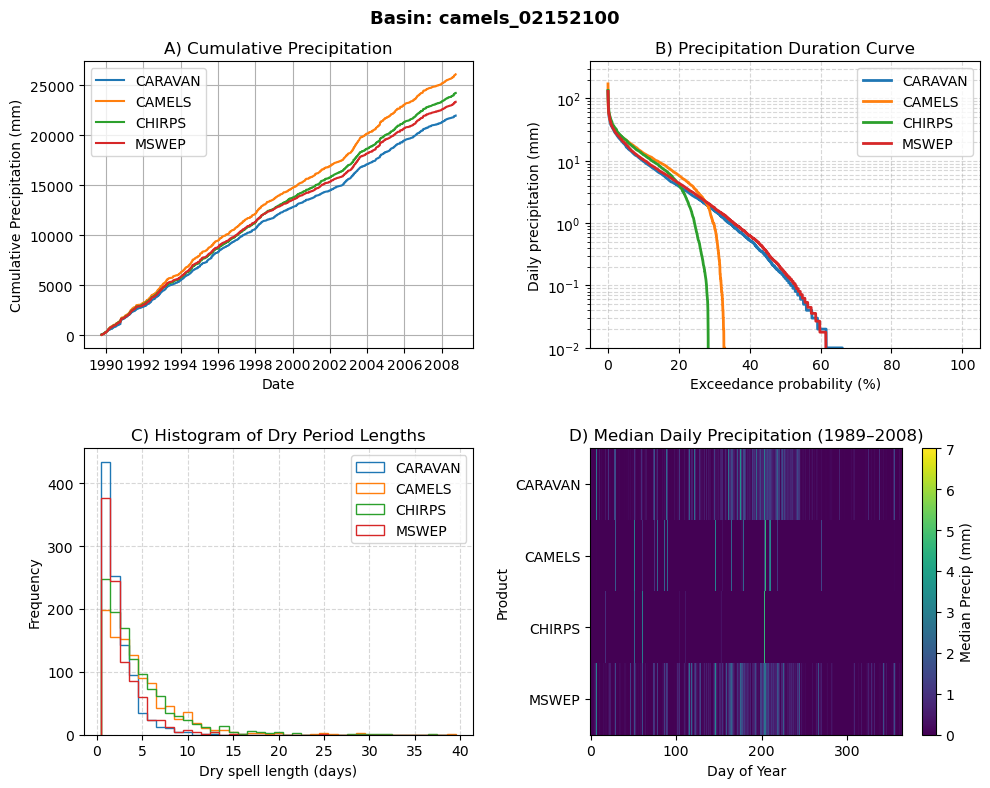

In [5]:
plot_precipitation_comparison(
        basin = "camels_02152100", #Biggest drop in NSE with no snow
        # basin="camels_05408000", #Biggest drop in NSE of the whole US
        extended_dataset_dir=extended_dataset_dir,
        data_caravan=data_caravan,
        data_camels=data_camels,
        # save_path=output_dir / f"{basin}.png",  # remove to show interactively
    )

In [6]:
def plot_precipitation_comparison(
    basin: str,
    extended_dataset_dir: Path,
    data_caravan: Path,
    data_camels: Path,
    start_date: str = "1989-10-01",
    end_date: str = "2008-09-30",
    vmax_heatmap: float = 7.0,
    save_path: Path = None,
):
    """
    Plot precipitation comparison for a single basin across four products:
    CARAVAN, CAMELS (gauge), CHIRPS, and MSWEP.

    Parameters
    ----------
    basin : str
        Basin ID, e.g. "camels_us_01013500"
    extended_dataset_dir : Path
        Directory containing extended NetCDF files (with CHIRPS/MSWEP).
    data_caravan : Path
        Directory containing original Caravan NetCDF files.
    data_camels : Path
        Directory containing CAMELS gauge txt files.
    start_date : str
        Start of analysis period (inclusive), default "1989-10-01".
    end_date : str
        End of analysis period (inclusive), default "2008-09-30".
    vmax_heatmap : float
        Max value for the seasonal heatmap colorbar, default 7.
    save_path : Path, optional
        If provided, saves the figure to this path instead of showing it.
    """
    number = basin.split("_")[-1]

    # ------------------------------------------------------------------ #
    # Load data
    # ------------------------------------------------------------------ #
    camels_nc = xr.open_dataset(extended_dataset_dir / f"{basin}.nc")

    csv_files = list(data_camels.glob(f"**/{number}*.txt"))
    if not csv_files:
        print(f"No gauge CSV found for {basin} — skipping.")
        return

    df_gauge = pd.read_csv(csv_files[0], skiprows=3, sep=r"\s+")
    df_gauge["date"] = pd.to_datetime(
        df_gauge[["Year", "Mnth", "Day"]].rename(
            columns={"Year": "year", "Mnth": "month", "Day": "day"}
        )
    )
    df_gauge = df_gauge.set_index("date")

    # ------------------------------------------------------------------ #
    # Build xarray DataArrays
    # ------------------------------------------------------------------ #
    precip_caravan = camels_nc["total_precipitation_sum"]
    precip_chirps  = camels_nc["chirps_precipitation"]
    precip_mswep   = camels_nc["mswep_precipitation"]
    precip_camels  = xr.DataArray(
        df_gauge["prcp(mm/day)"],
        coords={"date": df_gauge.index},
        dims="date",
        name="prcp",
    )

    # ------------------------------------------------------------------ #
    # Align and slice
    # ------------------------------------------------------------------ #
    precip_caravan, precip_camels, precip_chirps, precip_mswep = xr.align(
        precip_caravan, precip_camels, precip_chirps, precip_mswep, join="inner"
    )

    t0, t1 = pd.Timestamp(start_date), pd.Timestamp(end_date)
    sl = slice(t0, t1)

    caravan = precip_caravan.sel(date=sl)
    camels  = precip_camels.sel(date=sl)
    chirps  = precip_chirps.sel(date=sl)
    mswep   = precip_mswep.sel(date=sl)

    # ------------------------------------------------------------------ #
    # Cumulative sums
    # ------------------------------------------------------------------ #
    cum_caravan = caravan.cumsum(dim="date").values.flatten()
    cum_camels  = camels.cumsum(dim="date").values.flatten()
    cum_chirps  = chirps.cumsum(dim="date").values.flatten()
    cum_mswep   = mswep.cumsum(dim="date").values.flatten()

    # ------------------------------------------------------------------ #
    # Flow duration curve
    # ------------------------------------------------------------------ #
    def _fdc(da):
        arr = da.values.flatten()
        arr = arr[~np.isnan(arr)]
        arr_sorted = np.sort(arr)[::-1]
        ep = np.arange(1, len(arr_sorted) + 1) / (len(arr_sorted) + 1) * 100
        arr_plot = np.where(arr_sorted == 0, 1e-5, arr_sorted)
        return ep, arr_plot

    ep_caravan, pr_caravan_plot = _fdc(caravan)
    ep_camels,  pr_camels_plot  = _fdc(camels)
    ep_chirps,  pr_chirps_plot  = _fdc(chirps)
    ep_mswep,   pr_mswep_plot   = _fdc(mswep)

    # ------------------------------------------------------------------ #
    # Dry period lengths
    # ------------------------------------------------------------------ #
    def _dry_lengths(da):
        mask   = (da.values.flatten() == 0)
        diff   = np.diff(mask.astype(int))
        starts = np.where(diff == 1)[0] + 1
        ends   = np.where(diff == -1)[0] + 1
        if mask[0]:  starts = np.r_[0, starts]
        if mask[-1]: ends   = np.r_[ends, len(mask)]
        return ends - starts

    dry_caravan = _dry_lengths(caravan)
    dry_camels  = _dry_lengths(camels)
    dry_chirps  = _dry_lengths(chirps)
    dry_mswep   = _dry_lengths(mswep)

    bins = np.arange(1, max(dry_caravan.max(), dry_camels.max(),
                            dry_chirps.max(), dry_mswep.max()) + 2) - 0.5

    # ------------------------------------------------------------------ #
    # Seasonal cycle (median and mean by DOY)
    # ------------------------------------------------------------------ #
    dates  = pd.to_datetime(caravan.date.values)
    df_doy = pd.DataFrame({
        "doy":     dates.dayofyear,
        "caravan": caravan.values,
        "camels":  camels.values,
        "chirps":  chirps.values,
        "mswep":   mswep.values,
    })

    def _median_doy(col):
        med = df_doy.groupby("doy")[col].median().values
        return med[:365] if len(med) == 366 else med

    def _mean_doy(col):
        mn = df_doy.groupby("doy")[col].mean().values
        return mn[:365] if len(mn) == 366 else mn

    all_precip_median = np.array([
        _median_doy("caravan"),
        _median_doy("camels"),
        _median_doy("chirps"),
        _median_doy("mswep"),
    ])

    all_precip_mean = np.array([
        _mean_doy("caravan"),
        _mean_doy("camels"),
        _mean_doy("chirps"),
        _mean_doy("mswep"),
    ])

    # ------------------------------------------------------------------ #
    # Plot (2×3 grid, last slot hidden)
    # ------------------------------------------------------------------ #
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Basin: {basin}", fontsize=13, fontweight="bold")

    ax = axes

    # A) Cumulative
    max_val = max(cum_caravan.max(), cum_camels.max(),
                  cum_chirps.max(), cum_mswep.max())
    ax[0, 0].plot(cum_caravan, cum_camels, label="CAMELS")
    ax[0, 0].plot(cum_caravan, cum_chirps, label="CHIRPS")
    ax[0, 0].plot(cum_caravan, cum_mswep,  label="MSWEP")
    ax[0, 0].plot([0, max_val], [0, max_val], "r--", label="1:1 line")
    ax[0, 0].set(xlabel="Cumulative CARAVAN (mm)",
                 ylabel="Cumulative Precipitation (mm)",
                 title="A) Cumulative Precipitation Comparison")
    ax[0, 0].legend()
    ax[0, 0].grid(True)

    # B) Flow duration curve
    for ep, pr, lbl in [
        (ep_caravan, pr_caravan_plot, "CARAVAN"),
        (ep_camels,  pr_camels_plot,  "CAMELS"),
        (ep_chirps,  pr_chirps_plot,  "CHIRPS"),
        (ep_mswep,   pr_mswep_plot,   "MSWEP"),
    ]:
        ax[0, 1].plot(ep, pr, lw=2, label=lbl)
    ax[0, 1].set(xlabel="Exceedance probability (%)",
                 ylabel="Daily precipitation (mm)",
                 title="B) Precipitation Duration Curve",
                 yscale="log")
    ax[0, 1].legend()
    ax[0, 1].grid(True, which="both", ls="--", alpha=0.5)
    ax[0, 1].set_ylim(bottom=1e-2)

    # C) Dry period histogram
    for lengths, lbl in [
        (dry_caravan, "CARAVAN"),
        (dry_camels,  "CAMELS"),
        (dry_chirps,  "CHIRPS"),
        (dry_mswep,   "MSWEP"),
    ]:
        ax[0, 2].hist(lengths, bins=bins, histtype="step", lw=2, label=lbl)
    ax[0, 2].set(xlabel="Dry period length (days)",
                 ylabel="Frequency",
                 title="C) Histogram of Dry Period Lengths")
    ax[0, 2].legend()
    ax[0, 2].grid(True, ls="--", alpha=0.5)

    # D) Seasonal heatmap — median
    im1 = ax[1, 0].imshow(all_precip_median, aspect="auto", cmap="viridis",
                          vmin=0, vmax=vmax_heatmap, interpolation="nearest")
    ax[1, 0].set_yticks([0, 1, 2, 3])
    ax[1, 0].set_yticklabels(["CARAVAN", "CAMELS", "CHIRPS", "MSWEP"])
    ax[1, 0].set(xlabel="Day of Year", ylabel="Product",
                 title=f"D) Median Daily Precipitation ({start_date[:4]}–{end_date[:4]})")
    plt.colorbar(im1, ax=ax[1, 0]).set_label("Median Precip (mm)")

    # E) Seasonal heatmap — mean
    im2 = ax[1, 1].imshow(all_precip_mean, aspect="auto", cmap="viridis",
                          vmin=0, vmax=vmax_heatmap, interpolation="nearest")
    ax[1, 1].set_yticks([0, 1, 2, 3])
    ax[1, 1].set_yticklabels(["CARAVAN", "CAMELS", "CHIRPS", "MSWEP"])
    ax[1, 1].set(xlabel="Day of Year", ylabel="Product",
                 title=f"E) Mean Daily Precipitation ({start_date[:4]}–{end_date[:4]})")
    plt.colorbar(im2, ax=ax[1, 1]).set_label("Mean Precip (mm)")

    # hide last slot
    ax[1, 2].set_visible(False)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.35, wspace=0.3)

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved: {save_path}")
    else:
        plt.show()

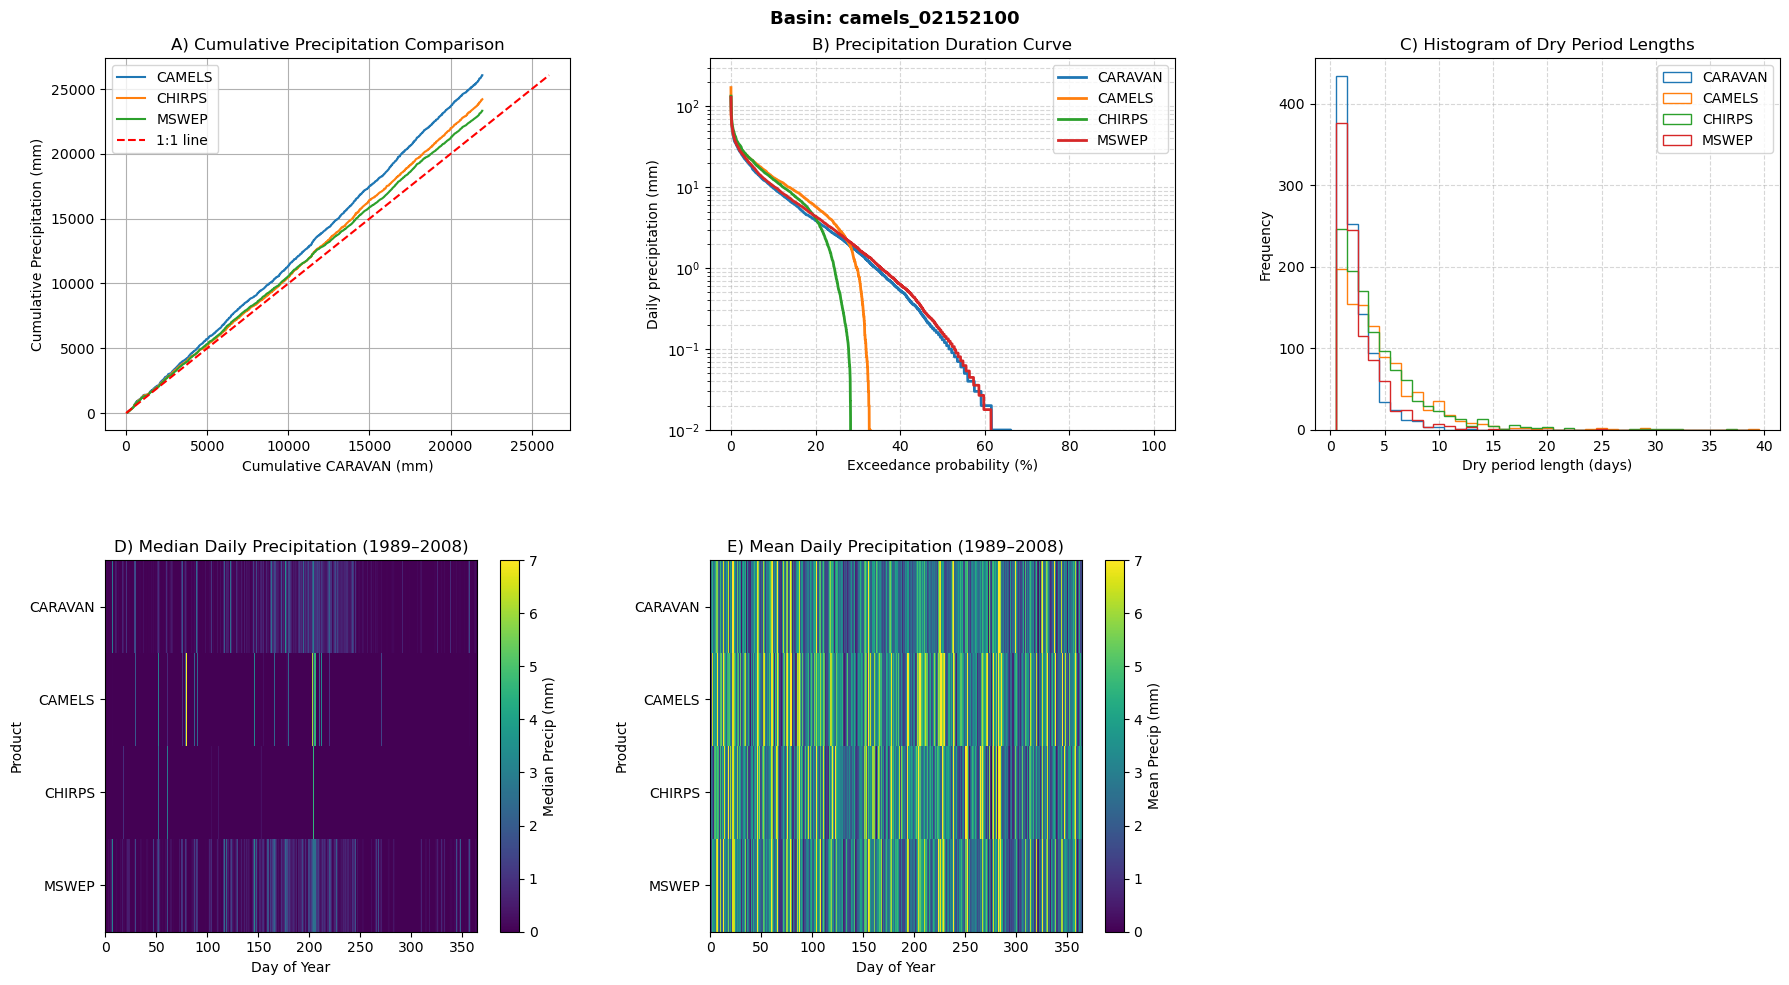

In [7]:
plot_precipitation_comparison(
        basin = "camels_02152100", #Biggest drop in NSE with no snow
        # basin="camels_05408000", #Biggest drop in NSE of the whole US
        extended_dataset_dir=extended_dataset_dir,
        data_caravan=data_caravan,
        data_camels=data_camels,
        # save_path=output_dir / f"{basin}.png",  # remove to show interactively
    )

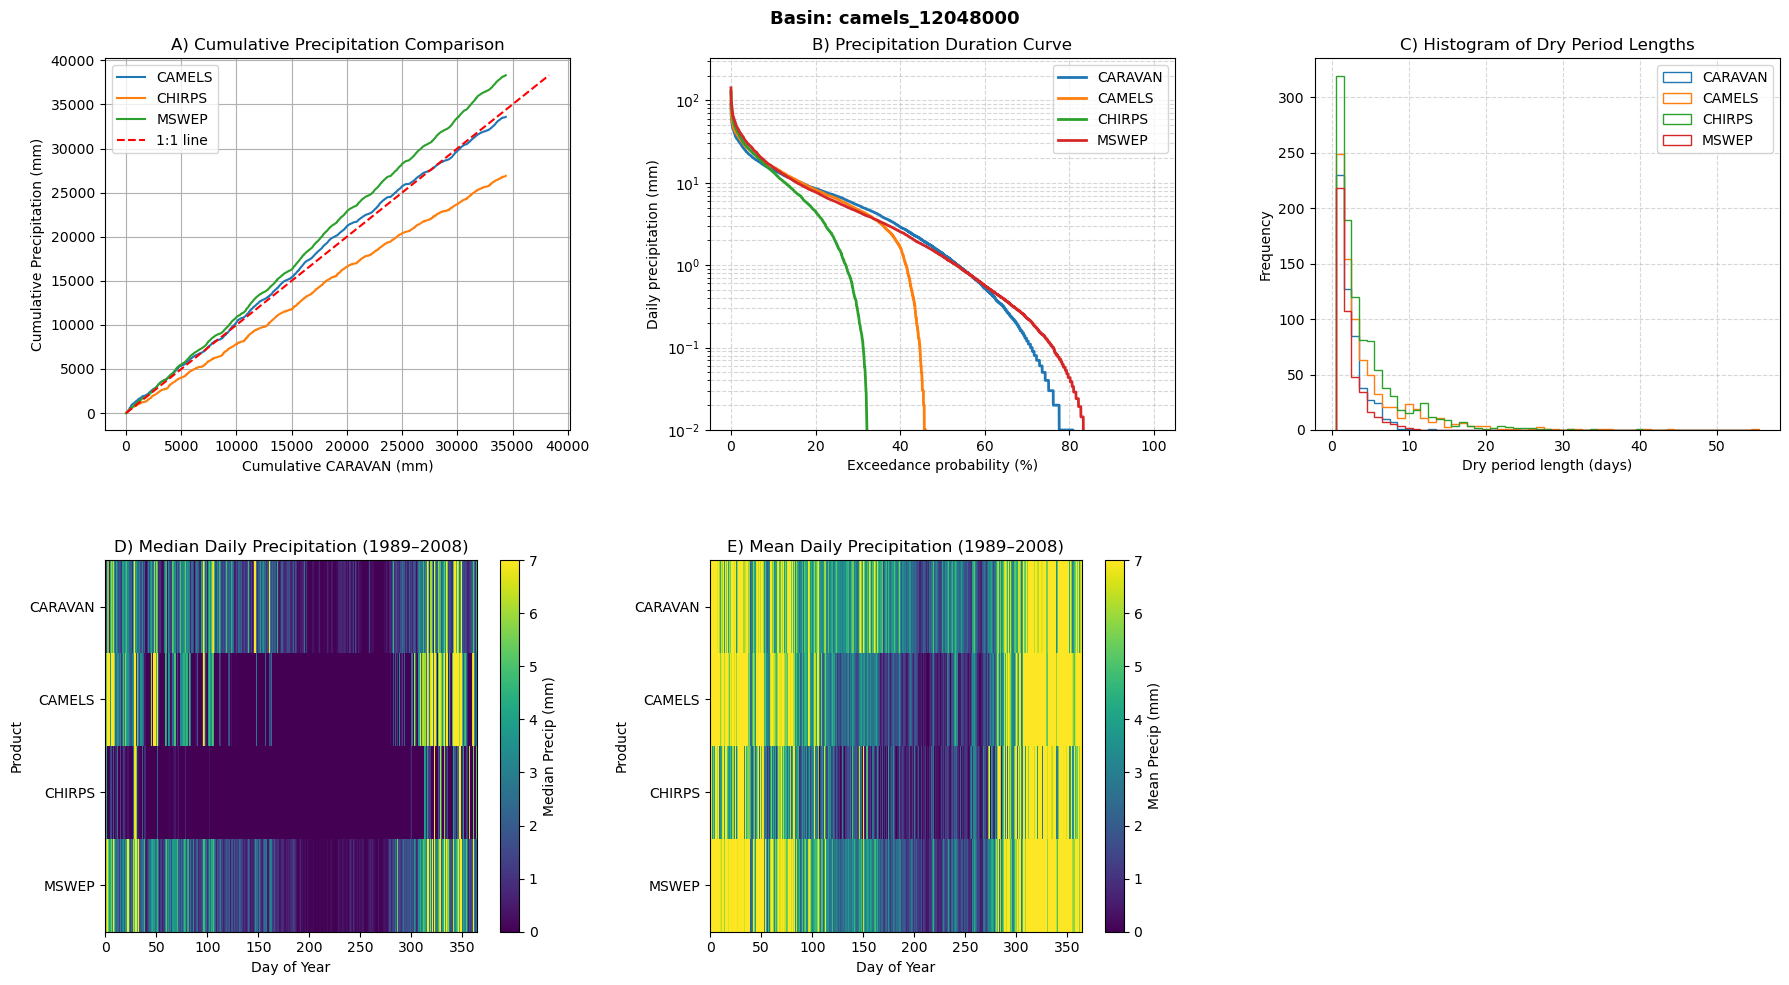

In [8]:
plot_precipitation_comparison(
        basin="camels_12048000", #Biggest increase in NSE
        extended_dataset_dir=extended_dataset_dir,
        data_caravan=data_caravan,
        data_camels=data_camels,
        # save_path=output_dir / f"{basin}.png",  # remove to show interactively
    )

Found 154 basins matching filter.
Processed 154 basins.


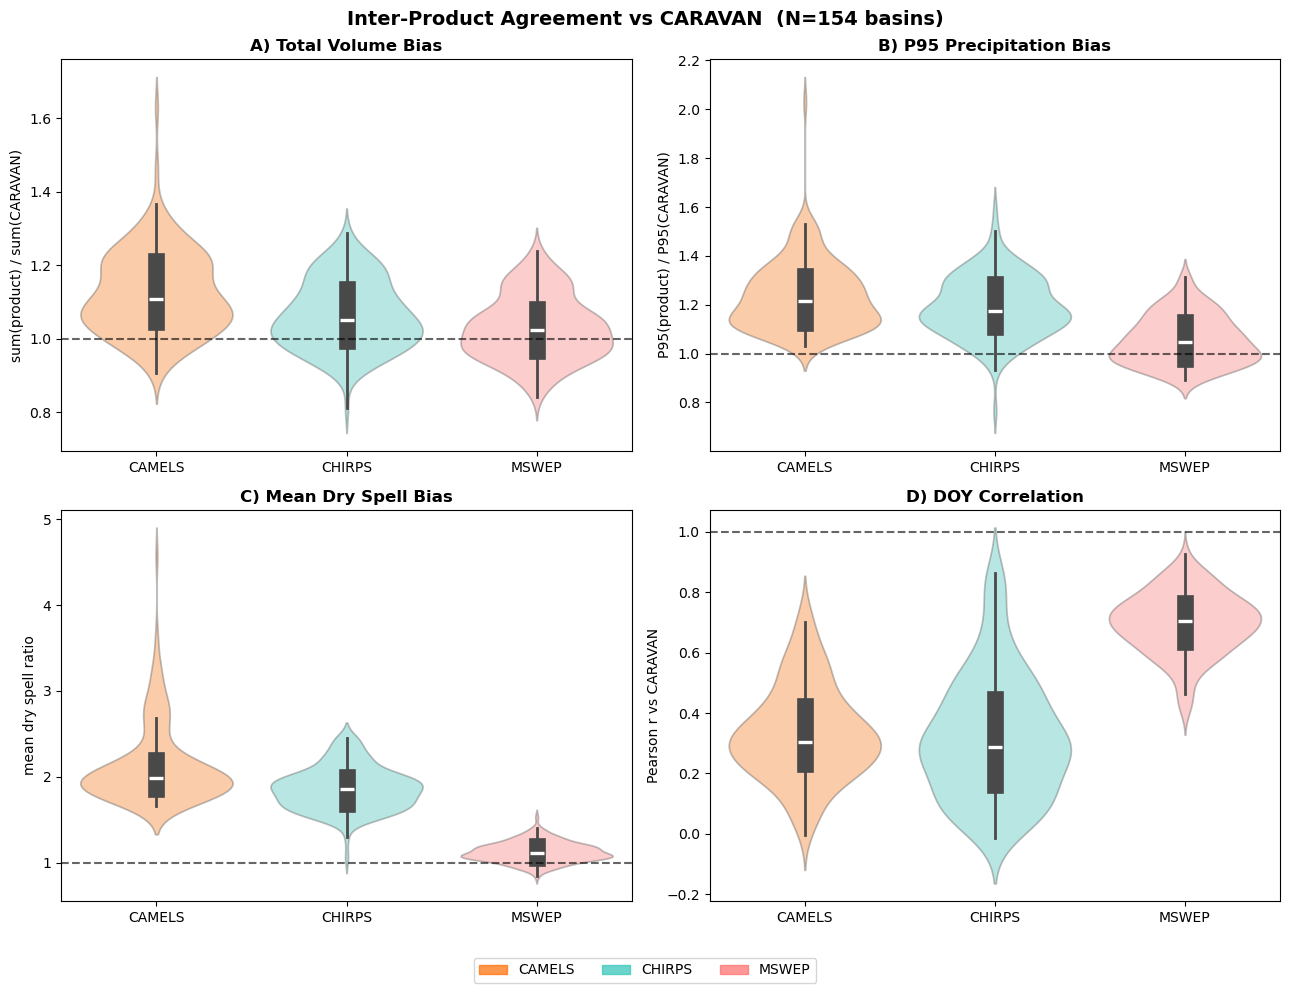

In [9]:
START_DATE = "1989-10-01"
END_DATE   = "2008-09-30"

PRODUCTS = ["CAMELS", "CHIRPS", "MSWEP"]
VAR_MAP  = {
    "CARAVAN": "total_precipitation_sum",
    "CHIRPS":  "chirps_precipitation",
    "MSWEP":   "mswep_precipitation",
    # CAMELS is loaded from txt, handled separately
}
PALETTE = {
    "CAMELS": "#FF6B00", #"#3A86FF",
    "CHIRPS": "#2EC4B6",
    "MSWEP":  "#FF6B6B",
}

# ── Metric helpers (unchanged) ─────────────────────────────────────────────────
def volume_ratio(arr, ref):
    s = np.nansum(ref)
    return np.nansum(arr) / s if s > 0 else np.nan

def p95_ratio(arr, ref):
    p = np.nanpercentile(ref, 95)
    return np.nanpercentile(arr, 95) / p if p > 0 else np.nan

def mean_dry_spell(arr):
    arr_clean = arr[~np.isnan(arr)]
    mask   = arr_clean == 0
    diff   = np.diff(mask.astype(int))
    starts = np.where(diff ==  1)[0] + 1
    ends   = np.where(diff == -1)[0] + 1
    if mask[0]:  starts = np.r_[0, starts]
    if mask[-1]: ends   = np.r_[ends, len(mask)]
    lengths = (ends - starts)
    lengths = lengths[lengths > 0]
    return np.mean(lengths) if len(lengths) > 0 else np.nan

def dry_spell_ratio(arr, ref):
    m_ref = mean_dry_spell(ref)
    m_arr = mean_dry_spell(arr)
    return m_arr / m_ref if (m_ref and not np.isnan(m_ref) and m_ref > 0) else np.nan

def seasonal_median(arr, dates):
    df   = pd.DataFrame({"doy": pd.DatetimeIndex(dates).dayofyear, "val": arr})
    med  = df.groupby("doy")["val"].median()
    full = pd.Series(0.0, index=np.arange(1, 366))
    full.update(med)
    return full.values

def seasonal_corr(arr, ref, dates):
    s_ref = seasonal_median(ref, dates)
    s_arr = seasonal_median(arr, dates)
    if np.std(s_ref) == 0 or np.std(s_arr) == 0:
        return np.nan
    r, _ = pearsonr(s_ref, s_arr)
    return r

# ── Load gauge txt (same logic as plot_precipitation_comparison) ───────────────
def load_gauge_txt(basin, data_camels):
    number    = basin.split("_")[-1]
    csv_files = list(data_camels.glob(f"**/{number}*.txt"))
    if not csv_files:
        return None
    df = pd.read_csv(csv_files[0], skiprows=3, sep=r"\s+")
    df["date"] = pd.to_datetime(
        df[["Year", "Mnth", "Day"]].rename(
            columns={"Year": "year", "Mnth": "month", "Day": "day"}
        )
    )
    return df.set_index("date")["prcp(mm/day)"]


# ── Load basin list ────────────────────────────────────────────────────────────
basins_file = Path("../basins_without_snow.txt")
basins_to_use = set(basins_file.read_text().splitlines())

# ── Load all basins → tidy DataFrame ──────────────────────────────────────────
records  = []
nc_files = [f for f in sorted(extended_dataset_dir.glob("*.nc"))
            if f.stem in basins_to_use]
print(f"Found {len(nc_files)} basins matching filter.")

# nc_files = sorted(extended_dataset_dir.glob("*.nc"))
# print(f"Found {len(nc_files)} basins.")

for nc_path in nc_files:
    basin = nc_path.stem
    try:
        ds    = xr.open_dataset(nc_path).sel(date=slice(START_DATE, END_DATE))
        dates = pd.to_datetime(ds["date"].values)
        ref   = ds[VAR_MAP["CARAVAN"]].values.flatten().astype(float)
        if np.nansum(ref) == 0:
            continue

        # Load gauge from txt
        gauge_series = load_gauge_txt(basin, data_camels)
        if gauge_series is None:
            continue
        camels_da = xr.DataArray(
            gauge_series,
            coords={"date": gauge_series.index},
            dims="date",
        ).sel(date=slice(START_DATE, END_DATE))

        arrays = {
            "CAMELS": camels_da.values.flatten().astype(float),
            "CHIRPS": ds[VAR_MAP["CHIRPS"]].values.flatten().astype(float),
            "MSWEP":  ds[VAR_MAP["MSWEP"]].values.flatten().astype(float),
        }

        for prod, arr in arrays.items():
            records.append({
                "basin":   basin,
                "product": prod,
                "vol":     volume_ratio(arr, ref),
                "p95":     p95_ratio(arr, ref),
                "dry":     dry_spell_ratio(arr, ref),
                "seas":    seasonal_corr(arr, ref, dates),
            })

    except Exception as e:
        print(f"  Skipping {basin}: {e}")

df = pd.DataFrame(records)
n_basins = df["basin"].nunique()
print(f"Processed {n_basins} basins.")

# ── Plot (unchanged from CAMELS-UY version) ────────────────────────────────────
PANEL_CFG = [
    ("vol",  "A) Total Volume Bias",      "sum(product) / sum(CARAVAN)"),
    ("p95",  "B) P95 Precipitation Bias", "P95(product) / P95(CARAVAN)"),
    ("dry",  "C) Mean Dry Spell Bias",    "mean dry spell ratio"),
    ("seas", "D) DOY Correlation",   "Pearson r vs CARAVAN"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle(f"Inter-Product Agreement vs CARAVAN  (N={n_basins} basins)",
             fontsize=14, fontweight="bold")

for ax, (col, title, ylabel) in zip(axes.flat, PANEL_CFG):
    sns.violinplot(
        data=df, x="product", y=col,
        hue="product", legend=False,
        palette=PALETTE, order=PRODUCTS,
        inner="box",
        inner_kws={"box_width": 12, "whis_width": 2},
        alpha=0.35, saturation=0.9,
        ax=ax,
    )
    # sns.stripplot(
    #     data=df, x="product", y=col,
    #     hue="product", legend=False,
    #     palette=PALETTE, order=PRODUCTS,
    #     size=3, alpha=0.3, jitter=True,
    #     ax=ax,
    # )

    ax.axhline(1.0, color="black", lw=1.5, ls="--", alpha=0.6)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")

legend_handles = [Patch(color=PALETTE[p], label=p, alpha=0.7) for p in PRODUCTS]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

Found 154 basins matching filter.
Processed 154 basins.


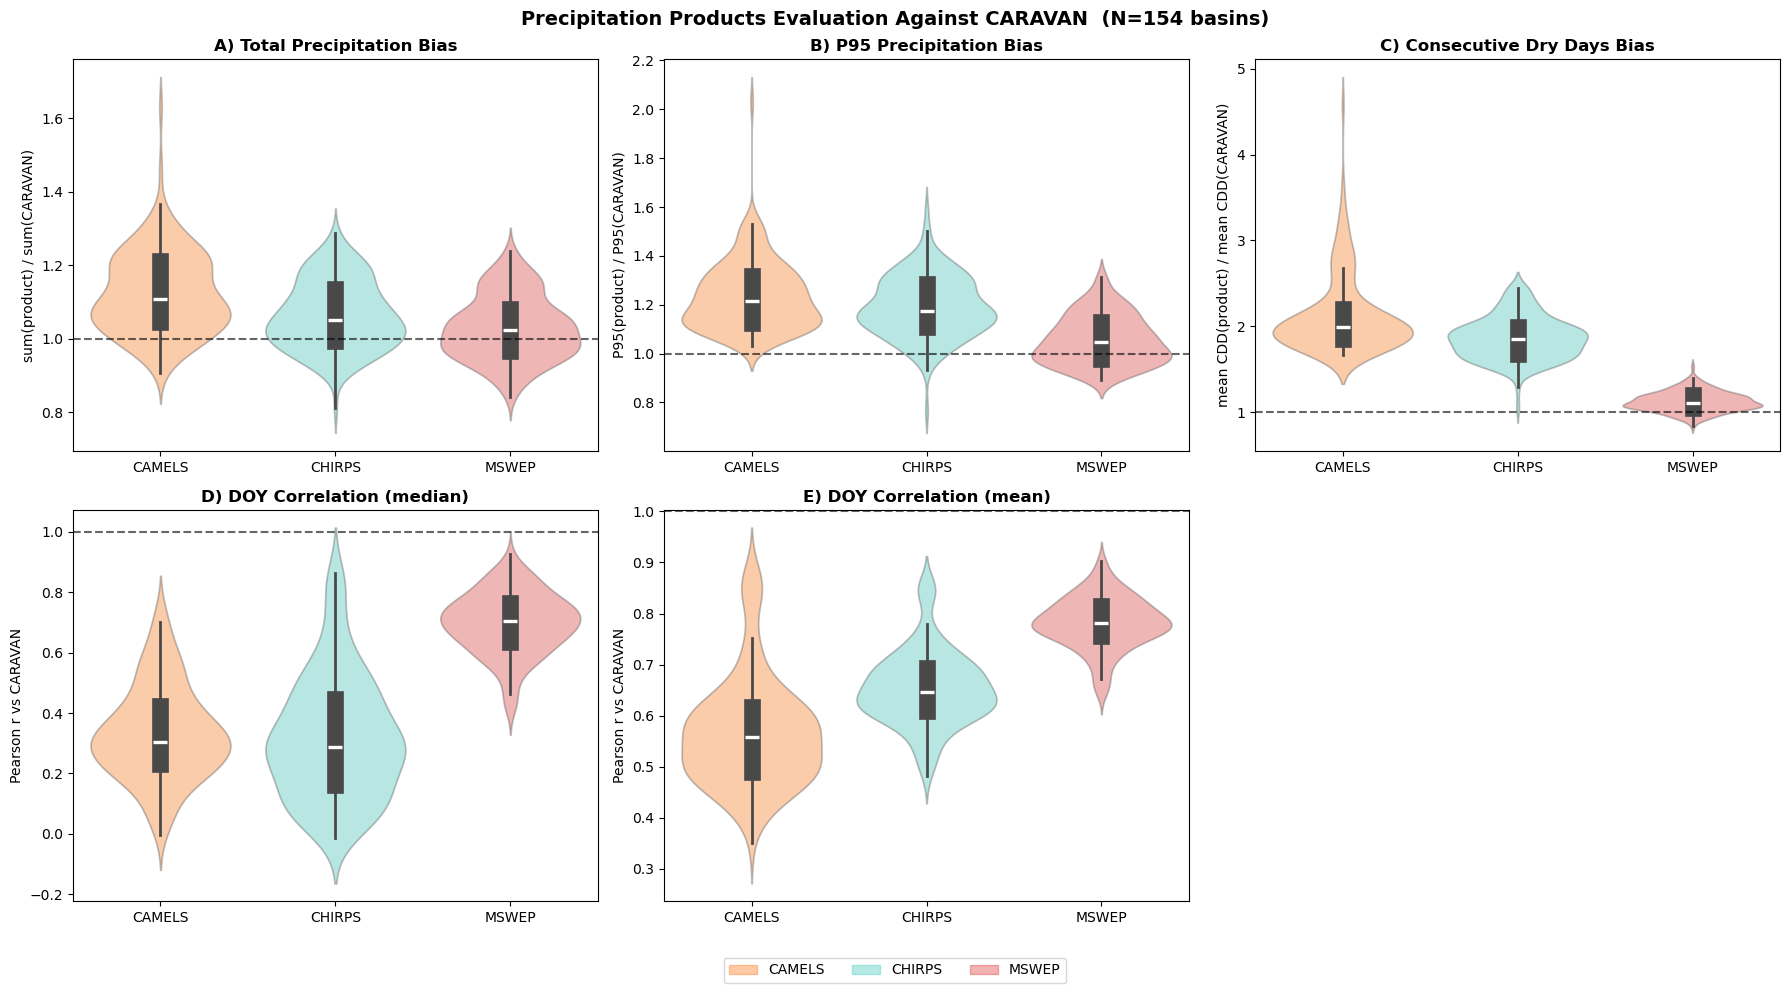

In [10]:
START_DATE = "1989-10-01"
END_DATE   = "2008-09-30"

PRODUCTS = ["CAMELS", "CHIRPS", "MSWEP"]
VAR_MAP  = {
    "CARAVAN": "total_precipitation_sum",
    "CHIRPS":  "chirps_precipitation",
    "MSWEP":   "mswep_precipitation",
}
PALETTE = {
    "CAMELS": "#FF6B00", #"#3A86FF",
    "CHIRPS": "#2EC4B6",
    "MSWEP":  "#DC2626",
}
# ── Metric helpers ─────────────────────────────────────────────────────────────
def volume_ratio(arr, ref):
    s = np.nansum(ref)
    return np.nansum(arr) / s if s > 0 else np.nan

def p95_ratio(arr, ref):
    p = np.nanpercentile(ref, 95)
    return np.nanpercentile(arr, 95) / p if p > 0 else np.nan

def mean_dry_spell(arr):
    arr_clean = arr[~np.isnan(arr)]
    mask   = arr_clean == 0
    diff   = np.diff(mask.astype(int))
    starts = np.where(diff ==  1)[0] + 1
    ends   = np.where(diff == -1)[0] + 1
    if mask[0]:  starts = np.r_[0, starts]
    if mask[-1]: ends   = np.r_[ends, len(mask)]
    lengths = (ends - starts)
    lengths = lengths[lengths > 0]
    return np.mean(lengths) if len(lengths) > 0 else np.nan

def dry_spell_ratio(arr, ref):
    m_ref = mean_dry_spell(ref)
    m_arr = mean_dry_spell(arr)
    return m_arr / m_ref if (m_ref and not np.isnan(m_ref) and m_ref > 0) else np.nan

def seasonal_median(arr, dates):
    df = pd.DataFrame({"doy": pd.DatetimeIndex(dates).dayofyear, "val": arr})
    med = df.groupby("doy")["val"].median()
    full = pd.Series(0.0, index=np.arange(1, 366))
    full.update(med)
    return full.values

def seasonal_corr(arr, ref, dates):
    s_ref = seasonal_median(ref, dates)
    s_arr = seasonal_median(arr, dates)
    if np.std(s_ref) == 0 or np.std(s_arr) == 0:
        return np.nan
    r, _ = pearsonr(s_ref, s_arr)
    return r

def seasonal_mean(arr, dates):
    df = pd.DataFrame({"doy": pd.DatetimeIndex(dates).dayofyear, "val": arr})
    mn = df.groupby("doy")["val"].mean()
    full = pd.Series(0.0, index=np.arange(1, 366))
    full.update(mn)
    return full.values

def seasonal_corr_mean(arr, ref, dates):
    s_ref = seasonal_mean(ref, dates)
    s_arr = seasonal_mean(arr, dates)
    if np.std(s_ref) == 0 or np.std(s_arr) == 0:
        return np.nan
    r, _ = pearsonr(s_ref, s_arr)
    return r

# ── Load gauge txt ─────────────────────────────────────────────────────────────
def load_gauge_txt(basin, data_camels):
    number    = basin.split("_")[-1]
    csv_files = list(data_camels.glob(f"**/{number}*.txt"))
    if not csv_files:
        return None
    df = pd.read_csv(csv_files[0], skiprows=3, sep=r"\s+")
    df["date"] = pd.to_datetime(
        df[["Year", "Mnth", "Day"]].rename(
            columns={"Year": "year", "Mnth": "month", "Day": "day"}
        )
    )
    return df.set_index("date")["prcp(mm/day)"]

# ── Load basin list ────────────────────────────────────────────────────────────
basins_file   = Path("../basins_without_snow.txt")
basins_to_use = set(basins_file.read_text().splitlines())

# ── Load all basins → tidy DataFrame ──────────────────────────────────────────
records  = []
nc_files = [f for f in sorted(extended_dataset_dir.glob("*.nc"))
            if f.stem in basins_to_use]
print(f"Found {len(nc_files)} basins matching filter.")

for nc_path in nc_files:
    basin = nc_path.stem
    try:
        ds    = xr.open_dataset(nc_path).sel(date=slice(START_DATE, END_DATE))
        dates = pd.to_datetime(ds["date"].values)
        ref   = ds[VAR_MAP["CARAVAN"]].values.flatten().astype(float)
        if np.nansum(ref) == 0:
            continue

        gauge_series = load_gauge_txt(basin, data_camels)
        if gauge_series is None:
            continue
        camels_da = xr.DataArray(
            gauge_series,
            coords={"date": gauge_series.index},
            dims="date",
        ).sel(date=slice(START_DATE, END_DATE))

        arrays = {
            "CAMELS": camels_da.values.flatten().astype(float),
            "CHIRPS": ds[VAR_MAP["CHIRPS"]].values.flatten().astype(float),
            "MSWEP":  ds[VAR_MAP["MSWEP"]].values.flatten().astype(float),
        }

        for prod, arr in arrays.items():
            records.append({
                "basin":     basin,
                "product":   prod,
                "vol":       volume_ratio(arr, ref),
                "p95":       p95_ratio(arr, ref),
                "dry":       dry_spell_ratio(arr, ref),
                "seas":      seasonal_corr(arr, ref, dates),
                "seas_mean": seasonal_corr_mean(arr, ref, dates),
            })

    except Exception as e:
        print(f"  Skipping {basin}: {e}")

df = pd.DataFrame(records)
n_basins = df["basin"].nunique()
print(f"Processed {n_basins} basins.")

# ── Panel config ───────────────────────────────────────────────────────────────
PANEL_CFG = [
    ("vol",       "A) Total Precipitation Bias",      "sum(product) / sum(CARAVAN)"),
    ("p95",       "B) P95 Precipitation Bias",        "P95(product) / P95(CARAVAN)"),
    ("dry",       "C) Consecutive Dry Days Bias",     "mean CDD(product) / mean CDD(CARAVAN)"),
    ("seas",      "D) DOY Correlation (median)", "Pearson r vs CARAVAN"),
    ("seas_mean", "E) DOY Correlation (mean)",   "Pearson r vs CARAVAN"),
]

# ── Plot (2×3 grid, middle bottom slot hidden) ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f"Precipitation Products Evaluation Against CARAVAN  (N={n_basins} basins)",
             fontsize=14, fontweight="bold")

axes[1, 2].set_visible(False)

plot_axes = [axes[0,0], axes[0,1], axes[0,2], axes[1,0], axes[1,1]]

for ax, (col, title, ylabel) in zip(plot_axes, PANEL_CFG):
    sns.violinplot(
        data=df, x="product", y=col,
        hue="product", legend=False,
        palette=PALETTE, order=PRODUCTS,
        inner="box",
        inner_kws={"box_width": 12, "whis_width": 2},
        alpha=0.35, saturation=0.9,
        ax=ax,
    )
    ax.axhline(1.0, color="black", lw=1.5, ls="--", alpha=0.6)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")

legend_handles = [Patch(color=PALETTE[p], label=p, alpha=0.35) for p in PRODUCTS]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

Found 154 basins matching filter.
Processed 154 basins.


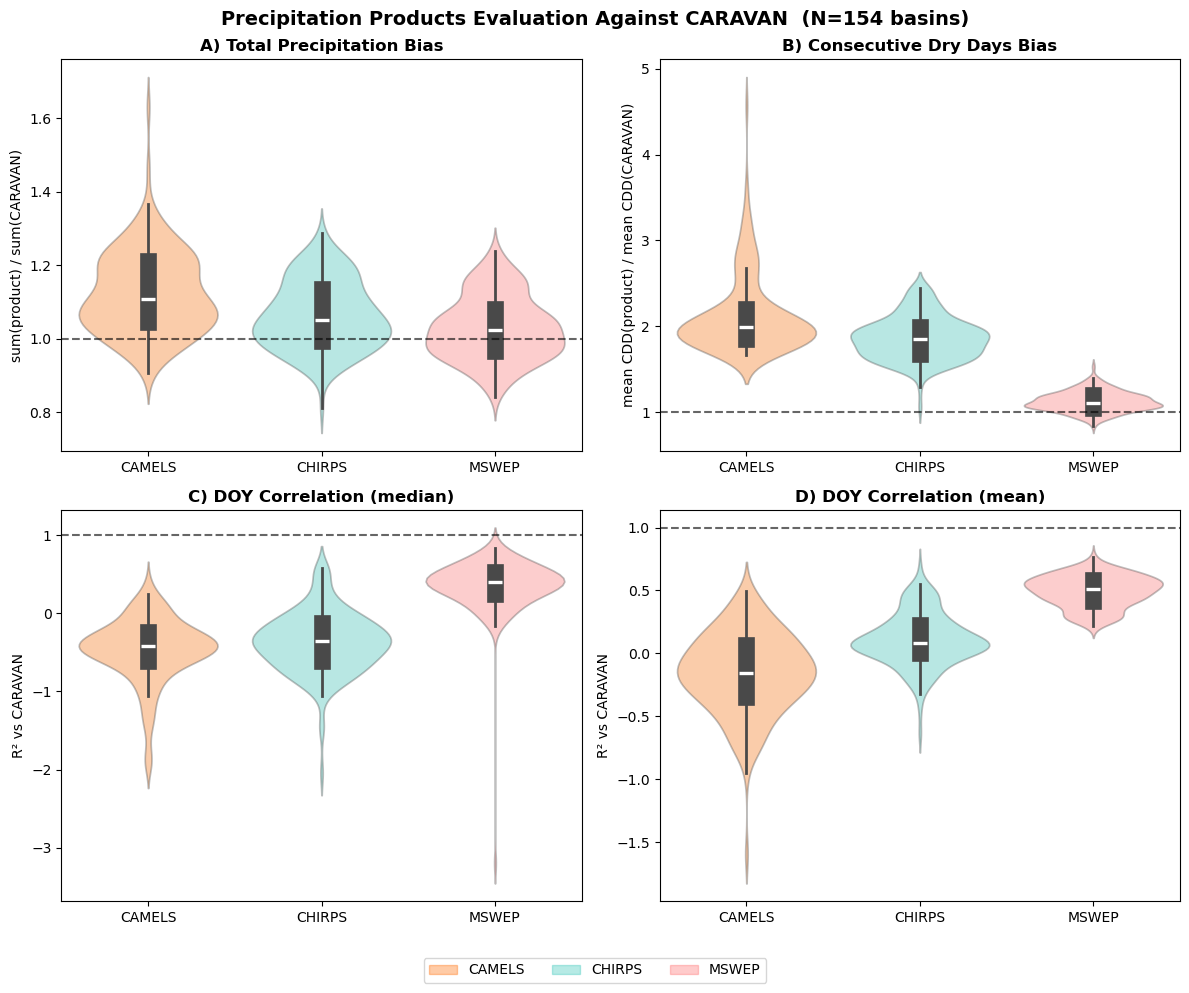

In [24]:
START_DATE = "1989-10-01"
END_DATE   = "2008-09-30"

PRODUCTS = ["CAMELS", "CHIRPS", "MSWEP"]
VAR_MAP  = {
    "CARAVAN": "total_precipitation_sum",
    "CHIRPS":  "chirps_precipitation",
    "MSWEP":   "mswep_precipitation",
}
PALETTE = {
    "CAMELS": "#FF6B00", #"#3A86FF",
    "CHIRPS": "#2EC4B6",
    "MSWEP":  "#FF6B6B",
}

# ── Metric helpers ─────────────────────────────────────────────────────────────
def volume_ratio(arr, ref):
    s = np.nansum(ref)
    return np.nansum(arr) / s if s > 0 else np.nan

def p95_ratio(arr, ref):
    p = np.nanpercentile(ref, 95)
    return np.nanpercentile(arr, 95) / p if p > 0 else np.nan

def mean_dry_spell(arr):
    arr_clean = arr[~np.isnan(arr)]
    mask   = arr_clean == 0
    diff   = np.diff(mask.astype(int))
    starts = np.where(diff ==  1)[0] + 1
    ends   = np.where(diff == -1)[0] + 1
    if mask[0]:  starts = np.r_[0, starts]
    if mask[-1]: ends   = np.r_[ends, len(mask)]
    lengths = (ends - starts)
    lengths = lengths[lengths > 0]
    return np.mean(lengths) if len(lengths) > 0 else np.nan

def dry_spell_ratio(arr, ref):
    m_ref = mean_dry_spell(ref)
    m_arr = mean_dry_spell(arr)
    return m_arr / m_ref if (m_ref and not np.isnan(m_ref) and m_ref > 0) else np.nan

def seasonal_median(arr, dates):
    df = pd.DataFrame({"doy": pd.DatetimeIndex(dates).dayofyear, "val": arr})
    med = df.groupby("doy")["val"].median()
    full = pd.Series(0.0, index=np.arange(1, 366))
    full.update(med)
    return full.values

def seasonal_corr(arr, ref, dates):
    s_ref = seasonal_median(ref, dates)
    s_arr = seasonal_median(arr, dates)
    if np.std(s_ref) == 0:
        return np.nan
    return r2_score(s_ref, s_arr)

def seasonal_mean(arr, dates):
    df = pd.DataFrame({"doy": pd.DatetimeIndex(dates).dayofyear, "val": arr})
    mn = df.groupby("doy")["val"].mean()
    full = pd.Series(0.0, index=np.arange(1, 366))
    full.update(mn)
    return full.values

def seasonal_corr_mean(arr, ref, dates):
    s_ref = seasonal_mean(ref, dates)
    s_arr = seasonal_mean(arr, dates)
    if np.std(s_ref) == 0:
        return np.nan
    return r2_score(s_ref, s_arr)

# ── Load gauge txt ─────────────────────────────────────────────────────────────
def load_gauge_txt(basin, data_camels):
    number    = basin.split("_")[-1]
    csv_files = list(data_camels.glob(f"**/{number}*.txt"))
    if not csv_files:
        return None
    df = pd.read_csv(csv_files[0], skiprows=3, sep=r"\s+")
    df["date"] = pd.to_datetime(
        df[["Year", "Mnth", "Day"]].rename(
            columns={"Year": "year", "Mnth": "month", "Day": "day"}
        )
    )
    return df.set_index("date")["prcp(mm/day)"]

# ── Load basin list ────────────────────────────────────────────────────────────
basins_file   = Path("../basins_without_snow.txt")
basins_to_use = set(basins_file.read_text().splitlines())

# ── Load all basins → tidy DataFrame ──────────────────────────────────────────
records  = []
nc_files = [f for f in sorted(extended_dataset_dir.glob("*.nc"))
            if f.stem in basins_to_use]
print(f"Found {len(nc_files)} basins matching filter.")

for nc_path in nc_files:
    basin = nc_path.stem
    try:
        ds    = xr.open_dataset(nc_path).sel(date=slice(START_DATE, END_DATE))
        dates = pd.to_datetime(ds["date"].values)
        ref   = ds[VAR_MAP["CARAVAN"]].values.flatten().astype(float)
        if np.nansum(ref) == 0:
            continue

        gauge_series = load_gauge_txt(basin, data_camels)
        if gauge_series is None:
            continue
        camels_da = xr.DataArray(
            gauge_series,
            coords={"date": gauge_series.index},
            dims="date",
        ).sel(date=slice(START_DATE, END_DATE))

        arrays = {
            "CAMELS": camels_da.values.flatten().astype(float),
            "CHIRPS": ds[VAR_MAP["CHIRPS"]].values.flatten().astype(float),
            "MSWEP":  ds[VAR_MAP["MSWEP"]].values.flatten().astype(float),
        }

        for prod, arr in arrays.items():
            records.append({
                "basin":     basin,
                "product":   prod,
                "vol":       volume_ratio(arr, ref),
                # "p95":       p95_ratio(arr, ref),
                "dry":       dry_spell_ratio(arr, ref),
                "seas":      seasonal_corr(arr, ref, dates),
                "seas_mean": seasonal_corr_mean(arr, ref, dates),
            })

    except Exception as e:
        print(f"  Skipping {basin}: {e}")

df = pd.DataFrame(records)
n_basins = df["basin"].nunique()
print(f"Processed {n_basins} basins.")

# ── Panel config ───────────────────────────────────────────────────────────────
PANEL_CFG = [
    ("vol",       "A) Total Precipitation Bias",      "sum(product) / sum(CARAVAN)"),
    # ("p95",       "B) P95 Precipitation Bias",        "P95(product) / P95(CARAVAN)"),
    ("dry",       "B) Consecutive Dry Days Bias",     "mean CDD(product) / mean CDD(CARAVAN)"),
    ("seas",      "C) DOY Correlation (median)", "R² vs CARAVAN"),
    ("seas_mean", "D) DOY Correlation (mean)",   "R² vs CARAVAN"),
]

# ── Plot (2×3 grid, middle bottom slot hidden) ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f"Precipitation Products Evaluation Against CARAVAN  (N={n_basins} basins)",
             fontsize=14, fontweight="bold")

plot_axes = axes.flatten() 

# axes[1, 2].set_visible(False)

# plot_axes = [axes[0,0], axes[0,1], axes[0,2], axes[1,0], axes[1,1]]

for ax, (col, title, ylabel) in zip(plot_axes, PANEL_CFG):
    sns.violinplot(
        data=df, x="product", y=col,
        hue="product", legend=False,
        palette=PALETTE, order=PRODUCTS,
        inner="box",
        inner_kws={"box_width": 12, "whis_width": 2},
        alpha=0.35, saturation=0.9,
        ax=ax,
    )
    ax.axhline(1.0, color="black", lw=1.5, ls="--", alpha=0.6)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")

legend_handles = [Patch(color=PALETTE[p], label=p, alpha=0.35) for p in PRODUCTS]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## Map

In [12]:
with open(basins_path, "r") as f:
    basins = f.read().splitlines()

In [13]:
attributes_df = pd.read_csv(ATTRIBUTES_FILE)
attributes_df = attributes_df[attributes_df["gauge_id"].isin(basins)]
attributes_df.head()

,gauge_id,aridity_ERA5_LAND,aridity_FAO_PM,frac_snow,high_prec_dur,high_prec_freq,low_prec_dur,low_prec_freq,moisture_index_ERA5_LAND,moisture_index_FAO_PM,p_mean,pet_mean_ERA5_LAND,pet_mean_FAO_PM,seasonality_ERA5_LAND,seasonality_FAO_PM
23,camels_01181000,3.812841,0.517986,0.223071,1.100840,0.053799,3.200636,0.620192,-0.695785,0.505404,3.765760,14.358241,1.950612,0.370373,0.891910
31,camels_01411300,6.547902,0.850316,0.000000,1.119197,0.061054,3.687100,0.671047,-0.840849,0.202124,3.046962,19.951210,2.590882,0.108187,1.124564
40,camels_01440400,4.253795,0.574181,0.215014,1.122053,0.055373,3.328762,0.631348,-0.741846,0.456636,3.511197,14.935913,2.016063,0.243502,0.926743
46,camels_01487000,2.148131,0.816437,0.000000,1.140236,0.059548,3.677091,0.667967,-0.488015,0.228381,3.132572,6.729175,2.557548,0.497987,1.042386
47,camels_01491000,3.867294,0.828633,0.000000,1.126599,0.060301,3.702376,0.671800,-0.724998,0.220911,3.062986,11.845469,2.538091,0.219745,1.061539


In [14]:
basins_without_snow = attributes_df[attributes_df["frac_snow"] == 0]
basins_without_snow

,gauge_id,aridity_ERA5_LAND,aridity_FAO_PM,frac_snow,high_prec_dur,high_prec_freq,low_prec_dur,low_prec_freq,moisture_index_ERA5_LAND,moisture_index_FAO_PM,p_mean,pet_mean_ERA5_LAND,pet_mean_FAO_PM,seasonality_ERA5_LAND,seasonality_FAO_PM
31,camels_01411300,6.547902,0.850316,0.0,1.119197,0.061054,3.687100,0.671047,-0.840849,0.202124,3.046962,19.951210,2.590882,0.108187,1.124564
46,camels_01487000,2.148131,0.816437,0.0,1.140236,0.059548,3.677091,0.667967,-0.488015,0.228381,3.132572,6.729175,2.557548,0.497987,1.042386
47,camels_01491000,3.867294,0.828633,0.0,1.126599,0.060301,3.702376,0.671800,-0.724998,0.220911,3.062986,11.845469,2.538091,0.219745,1.061539
82,camels_01644000,6.478690,0.786511,0.0,1.146575,0.057290,3.723380,0.672553,-0.831573,0.262752,2.882359,18.673912,2.267007,0.166854,1.113510
84,camels_01664000,6.257002,0.787302,0.0,1.160563,0.056400,3.757483,0.670226,-0.827592,0.263094,2.907870,18.194550,2.289372,0.154660,1.079264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,camels_08200000,5.892580,1.480150,0.0,1.338816,0.055715,5.378307,0.695756,-0.818055,-0.206494,2.355404,13.879405,3.486350,0.179898,0.972996
478,camels_08202700,5.354751,1.543873,0.0,1.343802,0.055647,5.494394,0.704381,-0.799316,-0.236503,2.294640,12.287230,3.542635,0.203036,0.963851
510,camels_09484600,7.586109,3.427976,0.0,1.458609,0.060301,8.970454,0.810472,-0.844949,-0.632137,1.021377,7.748279,3.501256,0.309929,0.862510
547,camels_11124500,18.177790,2.793685,0.0,1.534381,0.053457,14.039216,0.882135,-0.916015,-0.427672,1.197652,21.770658,3.345862,0.244175,1.529678


In [15]:
basins_without_snow_list = basins_without_snow["gauge_id"]
basins_without_snow_list.to_csv("basins_without_snow.txt", index=False, header=False)

In [16]:
location = pd.read_csv(location_file)
location_without_snow = location[location["gauge_id"].isin(basins_without_snow_list)]
location_without_snow

,gauge_id,gauge_name,country,gauge_lat,gauge_lon,area
31,camels_01411300,TUCKAHOE RIVER AT HEAD OF RIVER NJ,United States of America,39.30694,-74.82056,79.230476
46,camels_01487000,"NANTICOKE RIVER NEAR BRIDGEVILLE, DE",United States of America,38.72833,-75.56186,187.283875
47,camels_01491000,"CHOPTANK RIVER NEAR GREENSBORO, MD",United States of America,38.99719,-75.78581,291.553355
82,camels_01644000,"GOOSE CREEK NEAR LEESBURG, VA",United States of America,39.01955,-77.57749,858.811596
84,camels_01664000,"RAPPAHANNOCK RIVER AT REMINGTON, VA",United States of America,38.53068,-77.81360,1603.511552
...,...,...,...,...,...,...
477,camels_08200000,"Hondo Ck nr Tarpley, TX",United States of America,29.56967,-99.24671,249.577750
478,camels_08202700,"Seco Ck at Rowe Ranch nr D'Hanis, TX",United States of America,29.37079,-99.28782,431.340606
510,camels_09484600,"PANTANO WASH NEAR VAIL, AZ.",United States of America,32.03591,-110.67758,1241.049373
547,camels_11124500,SANTA CRUZ C NR SANTA YNEZ CA,United States of America,34.59666,-119.90875,192.472798


In [17]:
import geopandas as gpd

# create GeoDataFrame (WGS84)
gdf_us = gpd.GeoDataFrame(
    location_without_snow,
    geometry=gpd.points_from_xy(
        location_without_snow["gauge_lon"],
        location_without_snow["gauge_lat"]
    ),
    crs="EPSG:4326"
)

# reproject to Web Mercator (needed for contextily)
gdf_us = gdf_us.to_crs(epsg=3857)

In [18]:
gdf_us

,gauge_id,gauge_name,country,gauge_lat,gauge_lon,area,geometry
31,camels_01411300,TUCKAHOE RIVER AT HEAD OF RIVER NJ,United States of America,39.30694,-74.82056,79.230476,POINT (-8328986.64 4765733.948)
46,camels_01487000,"NANTICOKE RIVER NEAR BRIDGEVILLE, DE",United States of America,38.72833,-75.56186,187.283875,POINT (-8411507.779 4682831.549)
47,camels_01491000,"CHOPTANK RIVER NEAR GREENSBORO, MD",United States of America,38.99719,-75.78581,291.553355,POINT (-8436437.779 4721269.072)
82,camels_01644000,"GOOSE CREEK NEAR LEESBURG, VA",United States of America,39.01955,-77.57749,858.811596,POINT (-8635886.684 4724472.329)
84,camels_01664000,"RAPPAHANNOCK RIVER AT REMINGTON, VA",United States of America,38.53068,-77.81360,1603.511552,POINT (-8662170.329 4654666.741)
...,...,...,...,...,...,...,...
477,camels_08200000,"Hondo Ck nr Tarpley, TX",United States of America,29.56967,-99.24671,249.577750,POINT (-11048093.22 3448354.002)
478,camels_08202700,"Seco Ck at Rowe Ranch nr D'Hanis, TX",United States of America,29.37079,-99.28782,431.340606,POINT (-11052669.564 3422924.474)
510,camels_09484600,"PANTANO WASH NEAR VAIL, AZ.",United States of America,32.03591,-110.67758,1241.049373,POINT (-12320571.848 3768025.296)
547,camels_11124500,SANTA CRUZ C NR SANTA YNEZ CA,United States of America,34.59666,-119.90875,192.472798,POINT (-13348180.992 4109203.047)


In [19]:
basin_biggest_drop = "camels_05408000"

[]

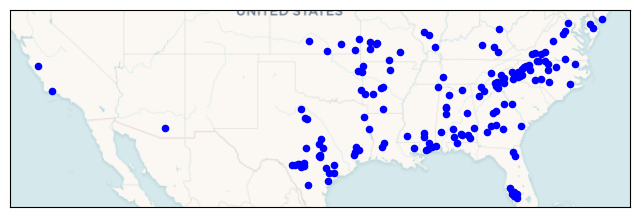

In [20]:
# ------------------------- PLOTTING -------------------------
# fig, ax = plt.subplots(2, 2, figsize=(15, 8))
fig, ax = plt.subplots(figsize=(8, 5))
# ---------------------------- ax[1,0]: Separate map of Uruguay basins ----------------------------
gdf_us.plot(
    ax=ax,
    color="blue",
    markersize=20,
    label="US Basins"
)

# ax[0].set_xlim(xmin, xmax)
# ax[0].set_ylim(ymin, ymax)

cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager, attribution=False)

# ax.set_title("A) Training Basins - US")
ax.set_xticks([])
ax.set_yticks([])

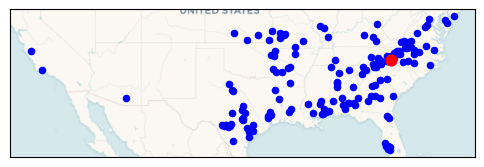

In [21]:
# --- Convert to GeoDataFrame ---
gdf_us = gpd.GeoDataFrame(
    location_without_snow,
    geometry=gpd.points_from_xy(
        location_without_snow["gauge_lon"],
        location_without_snow["gauge_lat"]
    ),
    crs="EPSG:4326"
)

# --- Reproject for basemap ---
gdf_us = gdf_us.to_crs(epsg=3857)

# --- Basin to highlight ---
basin_biggest_drop = "camels_02152100"

gdf_target = gdf_us[gdf_us["gauge_id"] == basin_biggest_drop]
gdf_others = gdf_us[gdf_us["gauge_id"] != basin_biggest_drop]

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

gdf_others.plot(
    ax=ax,
    color="blue",
    markersize=20
)

gdf_target.plot(
    ax=ax,
    color="red",
    markersize=60
)

cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager, attribution=False)

# ax.set_title("Training Basins - US")
ax.set_xticks([])
ax.set_yticks([])

plt.show()